# IT549: Deep Learning - Lab 3
## Image-Based AQI Classification using CNN and Pretrained Models

**Objective:** Predict `AQI_Class` from images of locations using two approaches:
1. A basic Convolutional Neural Network trained from scratch
2. A pretrained EfficientNet-B3 model using transfer learning

**Dataset:** `data.csv` (image paths and AQI class labels) and `sampled_images/` folder

**Pipeline Overview:**

| Task | Description |
|------|-------------|
| Task 1 | Data preparation: loading, resizing, normalization, and splits |
| Task 2 | Basic CNN model trained from scratch |
| Task 3 | Pretrained EfficientNet-B3 with transfer learning |
| Task 4 | Evaluation: accuracy, precision, recall, F1, confusion matrix |
| Task 5 | Training curves and discussion |
| Task 6 | Misclassification analysis |

## Imports

All library imports are collected here for clarity and easy dependency tracking.

In [1]:
import os
import time
import copy
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

# scikit-learn: splitting, label encoding, and evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)
from sklearn.preprocessing import LabelEncoder

# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# torchvision: transforms and pretrained models
from torchvision import transforms
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from torch.optim.lr_scheduler import CosineAnnealingLR

print("All imports successful.")

All imports successful.



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Deep\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Deep\AppData\Roaming\Python\Python311\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Deep\AppData\Roaming\Python\Python311\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.

## Configuration

All paths and hyperparameters are defined in one place. Edit this cell before running the notebook to match your directory structure.

In [2]:
# Paths
CSV_PATH   = "data.csv"                              # CSV with image_path and AQI_Class columns
IMAGE_DIR  = "sampled_images"                        # Folder containing all images
OUTPUT_DIR = "outputs"                               # Folder for saving plots and checkpoints
CNN_SAVE   = os.path.join(OUTPUT_DIR, "best_cnn_model.pth")
TL_SAVE    = os.path.join(OUTPUT_DIR, "best_tl_model.pth")

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Image size
IMG_SIZE = 224    # Standard size; EfficientNet-B3 also works well at 224

# Training hyperparameters
BATCH_SIZE     = 16
CNN_EPOCHS     = 20     # Epochs for the basic CNN
TL_EPOCHS      = 20     # Epochs for the transfer learning model
LR             = 3e-4
WEIGHT_DECAY   = 1e-4
DROPOUT        = 0.4
UNFREEZE_EPOCH = 5      # Epoch at which EfficientNet backbone is unfrozen

# Data split ratios (70 / 15 / 15)
TEST_SPLIT = 0.15
VAL_SPLIT  = 0.15

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("Configuration loaded.")

Configuration loaded.


## Device Setup

PyTorch automatically uses CUDA (GPU) when available. All tensors and models are moved to this device throughout the notebook.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU detected. Training will run on CPU and may be slow.")

Device : cuda
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 8.6 GB


---
# Task 1 - Data Preparation

This task covers:
- Loading `data.csv` and keeping only `image_path` and `AQI_Class`
- Encoding string class labels as integers
- Defining image transforms: resize to 224x224, normalization, and augmentation for training
- Creating stratified train / validation / test splits at 70 / 15 / 15
- Building a custom PyTorch Dataset and DataLoaders

### 1.1 Load and Explore the Dataset

We read the CSV, inspect the class distribution, and encode the `AQI_Class` string labels as integers so PyTorch's loss function can consume them.

In [4]:
df = pd.read_csv(CSV_PATH)

# Keep only the two required columns
df = df[["Filename", "AQI_Class"]].dropna().reset_index(drop=True)

print(f"Total samples : {len(df)}")
print(f"Columns used  : {list(df.columns)}\n")
print("Class distribution:")
print(df["AQI_Class"].value_counts())

Total samples : 6000
Columns used  : ['Filename', 'AQI_Class']

Class distribution:
AQI_Class
a_Good                              1000
b_Moderate                          1000
c_Unhealthy_for_Sensitive_Groups    1000
d_Unhealthy                         1000
e_Very_Unhealthy                    1000
f_Severe                            1000
Name: count, dtype: int64


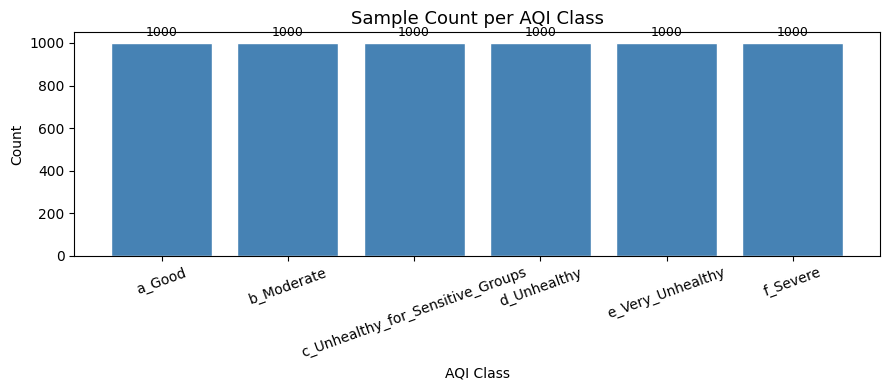

In [5]:
# Visualize class distribution
fig, ax = plt.subplots(figsize=(9, 4))
counts = df["AQI_Class"].value_counts()
bars = ax.bar(counts.index, counts.values, color="steelblue", edgecolor="white")

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            str(val), ha="center", va="bottom", fontsize=9)

ax.set_title("Sample Count per AQI Class", fontsize=13)
ax.set_xlabel("AQI Class")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Encode string class labels as integers
le = LabelEncoder()
df["label"] = le.fit_transform(df["AQI_Class"])
num_classes = len(le.classes_)

print(f"Number of classes : {num_classes}")
print("Class mapping:")
for idx, cls in enumerate(le.classes_):
    print(f"  {idx}  ->  {cls}")

Number of classes : 6
Class mapping:
  0  ->  a_Good
  1  ->  b_Moderate
  2  ->  c_Unhealthy_for_Sensitive_Groups
  3  ->  d_Unhealthy
  4  ->  e_Very_Unhealthy
  5  ->  f_Severe


### 1.2 Train / Validation / Test Split

A stratified split preserves the class proportions across all three subsets, which is important when class counts are unequal. The final ratio is 70% train, 15% validation, 15% test.

In [7]:
# Step 1: carve out the test set
train_val_df, test_df = train_test_split(
    df,
    test_size=TEST_SPLIT,
    stratify=df["label"],
    random_state=SEED
)

# Step 2: split the remainder into train and validation
# Re-scale VAL_SPLIT so the final proportion relative to the full dataset is correct
train_df, val_df = train_test_split(
    train_val_df,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    stratify=train_val_df["label"],
    random_state=SEED
)

print(f"Train : {len(train_df):>5} samples  ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val   : {len(val_df):>5} samples  ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test  : {len(test_df):>5} samples  ({len(test_df)/len(df)*100:.1f}%)")

Train :  4199 samples  (70.0%)
Val   :   901 samples  (15.0%)
Test  :   900 samples  (15.0%)


### 1.3 Image Transforms

The training transform applies random augmentations (random crop, horizontal flip, color jitter) to improve generalization and reduce overfitting. The evaluation transform is deterministic: resize and normalize only.

ImageNet mean and standard deviation values are used because the pretrained backbone was trained on ImageNet.

In [8]:
# ImageNet normalization statistics
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

def pil_to_float_tensor(img):
    """Convert PIL RGB image to float32 tensor in CHW format without NumPy."""
    img = img.convert("RGB")
    w, h = img.size
    tensor = torch.ByteTensor(torch.ByteStorage.from_buffer(img.tobytes()))
    tensor = tensor.view(h, w, 3).permute(2, 0, 1).contiguous()
    return tensor.float().div(255.0)

# Training pipeline: augmentation + normalization
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.05),
    transforms.Lambda(pil_to_float_tensor),
    transforms.Normalize(MEAN, STD),
])

# Evaluation pipeline: deterministic resize and normalize only
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(pil_to_float_tensor),
    transforms.Normalize(MEAN, STD),
])

print("Transforms defined.")
print(f"  Training pipeline : {len(train_transform.transforms)} steps")
print(f"  Eval pipeline     : {len(eval_transform.transforms)} steps")

Transforms defined.
  Training pipeline : 7 steps
  Eval pipeline     : 3 steps


### 1.4 Custom PyTorch Dataset and DataLoaders

`AQIDataset` wraps the dataframe and handles loading each image from disk, applying transforms, and returning a `(tensor, label)` pair. A black placeholder image is returned if a file is missing so the run does not abort.

In [9]:
class AQIDataset(Dataset):
    """
    Maps rows of the CSV to (image_tensor, int_label) pairs.

    Parameters
    ----------
    dataframe : pandas DataFrame with columns image_path and label
    image_dir : directory containing the image files
    transform : torchvision transform pipeline
    """

    def __init__(self, dataframe, image_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        fname = str(row["Filename"]).strip()
        label = int(row["label"])
        path  = os.path.join(self.image_dir, fname)

        try:
            img = Image.open(path).convert("RGB")
        except FileNotFoundError:
            img = Image.fromarray(np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8))

        if self.transform:
            img = self.transform(img)

        return img, label


# Instantiate datasets
train_ds = AQIDataset(train_df, IMAGE_DIR, train_transform)
val_ds   = AQIDataset(val_df,   IMAGE_DIR, eval_transform)
test_ds  = AQIDataset(test_df,  IMAGE_DIR, eval_transform)

# Wrap in DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"Train loader : {len(train_loader)} batches")
print(f"Val loader   : {len(val_loader)} batches")
print(f"Test loader  : {len(test_loader)} batches")

Train loader : 263 batches
Val loader   : 57 batches
Test loader  : 57 batches


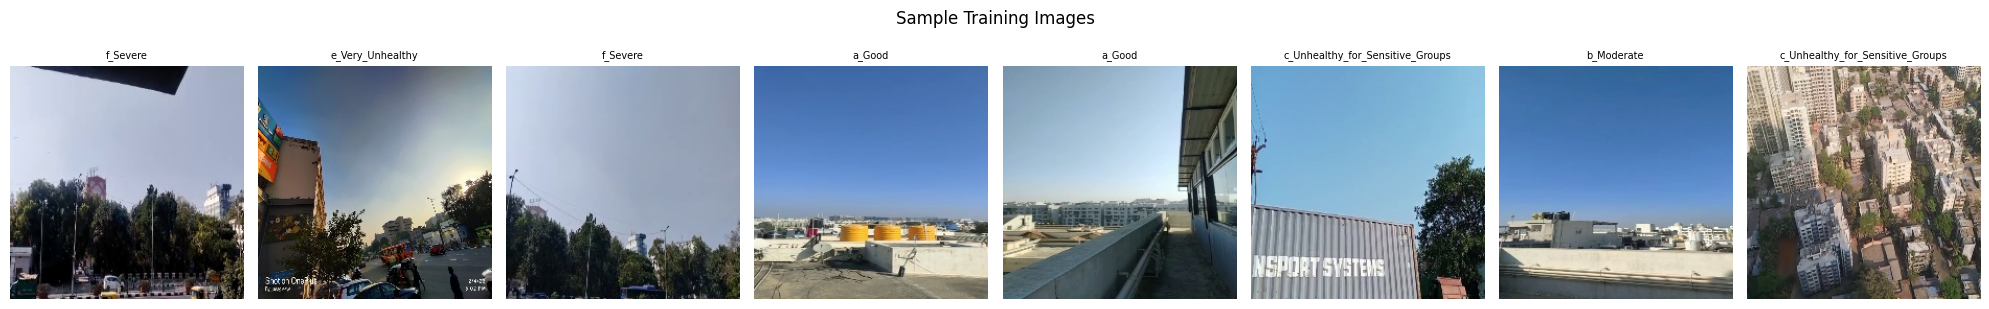

In [10]:
# Sanity check: visualize a batch of training images
debug_ds = AQIDataset(train_df, IMAGE_DIR, transform=eval_transform)
debug_loader = DataLoader(
    debug_ds,
    batch_size=8,
    shuffle=True,
    num_workers=0   # VERY IMPORTANT
)

def denorm(tensor):
    """Reverse ImageNet normalization for display."""
    mean = torch.tensor(MEAN, device=tensor.device).view(3, 1, 1)
    std  = torch.tensor(STD, device=tensor.device).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

sample_imgs, sample_labels = next(iter(debug_loader))

n_show = min(8, sample_imgs.size(0))
fig, axes = plt.subplots(1, n_show, figsize=(2.5 * n_show, 3))
if n_show == 1:
    axes = [axes]

for i in range(n_show):
    img_list = denorm(sample_imgs[i]).permute(1, 2, 0).cpu().tolist()
    label_idx = int(sample_labels[i].item())
    axes[i].imshow(img_list)
    axes[i].set_title(le.classes_[label_idx], fontsize=7)
    axes[i].axis("off")

plt.suptitle("Sample Training Images", y=1.02)
plt.tight_layout()
plt.show()

---
# Task 2 - Basic CNN Model

A Convolutional Neural Network is implemented from scratch without any pretrained weights. The architecture consists of three convolutional blocks followed by a fully connected classifier head.

Each convolutional block contains:
- A Conv2d layer with batch normalization and ReLU activation
- A MaxPool2d layer for spatial downsampling

The classifier head applies global average pooling to collapse spatial dimensions, followed by dropout and a linear output layer.

### 2.1 Define the CNN Architecture

In [12]:
class BasicCNN(nn.Module):
    """
    A simple CNN trained from scratch for AQI image classification.

    Architecture:
        Block 1: Conv(3->32)  + BN + ReLU + MaxPool
        Block 2: Conv(32->64) + BN + ReLU + MaxPool
        Block 3: Conv(64->128)+ BN + ReLU + MaxPool
        Head   : GlobalAvgPool -> Dropout -> Linear(128, num_classes)
    """

    def __init__(self, num_classes, dropout=0.4):
        super(BasicCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),        # 224 -> 112

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),        # 112 -> 56

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),        # 56 -> 28

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),        # 28 -> 14
        )

        # Global average pooling collapses (B, 256, 14, 14) -> (B, 256)
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)   # flatten
        x = self.classifier(x)
        return x


cnn_model = BasicCNN(num_classes=num_classes, dropout=DROPOUT).to(device)

total_params = sum(p.numel() for p in cnn_model.parameters())
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Model moved to       : {device}")

Total parameters     : 390,918
Trainable parameters : 390,918
Model moved to       : cuda


### 2.2 Training Utilities

The `run_epoch` function handles both training and evaluation passes. In training mode it computes gradients and updates weights. In eval mode it wraps the forward pass in `torch.no_grad()` to skip gradient computation.

In [15]:
from tqdm import tqdm

def run_epoch(loader, model, criterion, optimizer=None, phase="train"):
    """
    Execute one full pass over the DataLoader with live progress.
    """

    is_train = (phase == "train")
    model.train() if is_train else model.eval()

    running_loss  = 0.0
    correct       = 0
    total_samples = 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()

    # Progress bar
    pbar = tqdm(loader, desc=phase.upper(), leave=False)

    with ctx:
        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss   = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            running_loss  += loss.item() * images.size(0)
            preds          = logits.argmax(dim=1)
            correct       += (preds == labels).sum().item()
            total_samples += images.size(0)

            # Update progress bar with live stats
            current_loss = running_loss / total_samples
            current_acc  = correct / total_samples

            pbar.set_postfix({
                "loss": f"{current_loss:.4f}",
                "acc": f"{current_acc:.4f}"
            })

    avg_loss = running_loss / total_samples
    accuracy = correct / total_samples
    return avg_loss, accuracy

### 2.3 Train the Basic CNN

In [16]:
cnn_criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.AdamW(cnn_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
cnn_scheduler = CosineAnnealingLR(cnn_optimizer, T_max=CNN_EPOCHS)

cnn_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_cnn_val_acc = 0.0
best_cnn_wts     = copy.deepcopy(cnn_model.state_dict())

print(f"Training Basic CNN for {CNN_EPOCHS} epochs")
print(f"{'Epoch':>6}  {'Tr Loss':>8}  {'Tr Acc':>7}  {'Va Loss':>8}  {'Va Acc':>7}  {'Time':>6}")
print("-" * 55)

for epoch in range(1, CNN_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{CNN_EPOCHS}")
    t0 = time.time()

    tr_loss, tr_acc = run_epoch(train_loader, cnn_model, cnn_criterion, cnn_optimizer, "train")
    va_loss, va_acc = run_epoch(val_loader,   cnn_model, cnn_criterion, None,          "val")
    cnn_scheduler.step()

    if va_acc > best_cnn_val_acc:
        best_cnn_val_acc = va_acc
        best_cnn_wts     = copy.deepcopy(cnn_model.state_dict())
        torch.save(best_cnn_wts, CNN_SAVE)
        tag = "  * best"
    else:
        tag = ""

    cnn_history["train_loss"].append(tr_loss)
    cnn_history["train_acc"].append(tr_acc)
    cnn_history["val_loss"].append(va_loss)
    cnn_history["val_acc"].append(va_acc)

    elapsed = time.time() - t0
    print(f"{epoch:>6}  {tr_loss:>8.4f}  {tr_acc:>7.4f}  {va_loss:>8.4f}  {va_acc:>7.4f}  {elapsed:>5.1f}s{tag}")

print(f"\nTraining complete. Best Validation Accuracy (CNN): {best_cnn_val_acc:.4f}")
print(f"Checkpoint saved to: {CNN_SAVE}")

Training Basic CNN for 20 epochs
 Epoch   Tr Loss   Tr Acc   Va Loss   Va Acc    Time
-------------------------------------------------------

Epoch 1/20


     1    1.3706   0.4568    1.8795   0.3518   47.1s  * best

Epoch 2/20


     2    1.2858   0.4882    1.7485   0.4007   30.6s  * best

Epoch 3/20


     3    1.2381   0.5161    1.4126   0.4883   30.5s  * best

Epoch 4/20


     4    1.1848   0.5358    1.8915   0.3596   30.9s

Epoch 5/20


...

    16    0.8984   0.6387    1.6215   0.4750   32.0s

Epoch 17/20


    17    0.8859   0.6409    1.8031   0.4251   32.0s

Epoch 18/20


    18    0.8761   0.6533    1.4412   0.4994   31.7s  * best

Epoch 19/20


    19    0.8651   0.6628    1.7151   0.4462   31.5s

Epoch 20/20


    20    0.8472   0.6649    1.5658   0.4784   33.4s

Training complete. Best Validation Accuracy (CNN): 0.4994
Checkpoint saved to: outputs\best_cnn_model.pth


---
# Task 3 - Pretrained CNN Model (Transfer Learning)

EfficientNet-B3, pretrained on ImageNet, is used here. The backbone provides powerful feature extraction from its prelearned visual representations. Only the final classification head is replaced to match the number of AQI classes.

**Two-phase training strategy:**
- Phase 1 (epochs 1 to `UNFREEZE_EPOCH`): backbone is frozen; only the new head trains. This avoids destroying pretrained features early in training.
- Phase 2 (epoch `UNFREEZE_EPOCH` onwards): the full network is unfrozen. The backbone receives a 10x lower learning rate to preserve its features while the head fine-tunes aggressively.

### 3.1 Build the Transfer Learning Model

In [17]:
# Load EfficientNet-B3 with ImageNet weights
tl_model = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)

# Freeze all backbone parameters (Phase 1)
for param in tl_model.parameters():
    param.requires_grad = False

# Replace the classifier head to match our number of classes
in_features = tl_model.classifier[1].in_features   # 1536 for EfficientNet-B3
tl_model.classifier = nn.Sequential(
    nn.Dropout(p=DROPOUT, inplace=True),
    nn.Linear(in_features, num_classes)
)

tl_model = tl_model.to(device)

trainable = sum(p.numel() for p in tl_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in tl_model.parameters())
print(f"Total parameters     : {total:,}")
print(f"Trainable (head only): {trainable:,}")
print(f"Frozen (backbone)    : {total - trainable:,}")
print(f"Model moved to       : {device}")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to C:\Users\Deep/.cache\torch\hub\checkpoints\efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:27<00:00, 1.81MB/s]


Total parameters     : 10,705,454
Trainable (head only): 9,222
Frozen (backbone)    : 10,696,232
Model moved to       : cuda


### 3.2 Train the Transfer Learning Model

In [18]:
tl_criterion = nn.CrossEntropyLoss()
tl_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, tl_model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)
tl_scheduler = CosineAnnealingLR(tl_optimizer, T_max=TL_EPOCHS)

tl_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_tl_val_acc = 0.0
best_tl_wts     = copy.deepcopy(tl_model.state_dict())

print(f"Training EfficientNet-B3 (Transfer Learning) for {TL_EPOCHS} epochs")
print(f"Backbone unfreezes at epoch {UNFREEZE_EPOCH}\n")
print(f"{'Epoch':>6}  {'Tr Loss':>8}  {'Tr Acc':>7}  {'Va Loss':>8}  {'Va Acc':>7}  {'Time':>6}")
print("-" * 55)

for epoch in range(1, TL_EPOCHS + 1):
    t0 = time.time()

    # Phase 2: unfreeze backbone
    if epoch == UNFREEZE_EPOCH:
        print(f"\n  Epoch {epoch}: Unfreezing backbone for full fine-tuning.\n")
        for param in tl_model.parameters():
            param.requires_grad = True

        # Differential learning rates: backbone gets LR/10
        tl_optimizer = optim.AdamW(
            [
                {"params": tl_model.features.parameters(),   "lr": LR / 10},
                {"params": tl_model.classifier.parameters(), "lr": LR},
            ],
            weight_decay=WEIGHT_DECAY
        )
        tl_scheduler = CosineAnnealingLR(tl_optimizer, T_max=TL_EPOCHS - UNFREEZE_EPOCH)

    tr_loss, tr_acc = run_epoch(train_loader, tl_model, tl_criterion, tl_optimizer, "train")
    va_loss, va_acc = run_epoch(val_loader,   tl_model, tl_criterion, None,         "val")
    tl_scheduler.step()

    if va_acc > best_tl_val_acc:
        best_tl_val_acc = va_acc
        best_tl_wts     = copy.deepcopy(tl_model.state_dict())
        torch.save(best_tl_wts, TL_SAVE)
        tag = "  * best"
    else:
        tag = ""

    tl_history["train_loss"].append(tr_loss)
    tl_history["train_acc"].append(tr_acc)
    tl_history["val_loss"].append(va_loss)
    tl_history["val_acc"].append(va_acc)

    elapsed = time.time() - t0
    print(f"{epoch:>6}  {tr_loss:>8.4f}  {tr_acc:>7.4f}  {va_loss:>8.4f}  {va_acc:>7.4f}  {elapsed:>5.1f}s{tag}")

print(f"\nTraining complete. Best Validation Accuracy (Transfer Learning): {best_tl_val_acc:.4f}")
print(f"Checkpoint saved to: {TL_SAVE}")

Training EfficientNet-B3 (Transfer Learning) for 20 epochs
Backbone unfreezes at epoch 5

 Epoch   Tr Loss   Tr Acc   Va Loss   Va Acc    Time
-------------------------------------------------------


     1    1.5892   0.3922    6.8283   0.4717   34.4s  * best


     2    1.3437   0.5294    4.9341   0.5483   34.2s  * best


     3    1.2244   0.5663   10.8367   0.5549   34.2s  * best


     4    1.1700   0.5723   22.8983   0.5527   34.1s

  Epoch 5: Unfreezing backbone for full fine-tuning.



...

    16    0.1888   0.9340    8.9158   0.7869   49.7s


    17    0.1854   0.9395    8.5632   0.8124   48.5s  * best


    18    0.1691   0.9433    3.2654   0.8169   48.8s  * best


    19    0.1856   0.9338   14.6085   0.7936   48.4s


    20    0.1802   0.9350    7.2047   0.8002   48.4s

Training complete. Best Validation Accuracy (Transfer Learning): 0.8169
Checkpoint saved to: outputs\best_tl_model.pth


---
# Task 4 - Model Training and Evaluation

Both models are evaluated on the held-out test set using their best checkpoints (highest validation accuracy). Metrics reported: accuracy, precision, recall, F1-score (macro and weighted), and ROC-AUC. Confusion matrices are generated for both models.

### 4.1 Evaluation Helper Function

In [19]:
def evaluate_model(model, loader, checkpoint_path):
    """
    Load the best checkpoint and run inference on the test set.

    Returns
    -------
    all_preds  : numpy array of predicted class indices
    all_labels : numpy array of true class indices
    all_probs  : numpy array of softmax probabilities, shape (N, num_classes)
    """
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            logits = model(images)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            preds  = logits.argmax(dim=1).cpu().numpy()

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels), np.array(all_probs)


def print_metrics(preds, labels, probs, model_name):
    """Compute and print the standard evaluation metrics."""
    acc      = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro",    zero_division=0)
    wtd_f1   = f1_score(labels, preds, average="weighted", zero_division=0)

    try:
        if num_classes == 2:
            auc = roc_auc_score(labels, probs[:, 1])
        else:
            auc = roc_auc_score(labels, probs, multi_class="ovr", average="macro")
    except ValueError:
        auc = float("nan")

    print(f"\n{model_name} - Test Set Results")
    print("=" * 50)
    results = pd.DataFrame({
        "Metric": ["Accuracy", "Macro F1", "Weighted F1", "ROC-AUC (macro OvR)"],
        "Score" : [f"{acc:.4f}", f"{macro_f1:.4f}", f"{wtd_f1:.4f}", f"{auc:.4f}"]
    })
    print(results.to_string(index=False))

    print(f"\nPer-class Classification Report:")
    print("-" * 50)
    print(classification_report(labels, preds, target_names=list(le.classes_), zero_division=0))

    return acc, macro_f1, wtd_f1, auc


print("Evaluation functions defined.")

Evaluation functions defined.


### 4.2 Evaluate the Basic CNN on the Test Set

In [21]:
# Redefine with a NumPy-safe conversion path (avoids tensor.numpy())
def evaluate_model(model, loader, checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            logits = model(images)

            probs = torch.softmax(logits, dim=1).detach().cpu().tolist()
            preds = logits.argmax(dim=1).detach().cpu().tolist()
            labs  = labels.detach().cpu().tolist()

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labs)

    return (
        np.asarray(all_preds, dtype=np.int64),
        np.asarray(all_labels, dtype=np.int64),
        np.asarray(all_probs, dtype=np.float32),
    )

cnn_preds, cnn_labels, cnn_probs = evaluate_model(cnn_model, test_loader, CNN_SAVE)
cnn_acc, cnn_f1, cnn_wtd_f1, cnn_auc = print_metrics(cnn_preds, cnn_labels, cnn_probs, "Basic CNN")


Basic CNN - Test Set Results
             Metric  Score
           Accuracy 0.4911
           Macro F1 0.4843
        Weighted F1 0.4843
ROC-AUC (macro OvR) 0.8734

Per-class Classification Report:
--------------------------------------------------
                                  precision    recall  f1-score   support

                          a_Good       0.56      0.66      0.61       150
                      b_Moderate       0.31      0.86      0.46       150
c_Unhealthy_for_Sensitive_Groups       0.40      0.13      0.20       150
                     d_Unhealthy       0.56      0.39      0.46       150
                e_Very_Unhealthy       0.90      0.40      0.55       150
                        f_Severe       0.84      0.51      0.63       150

                        accuracy                           0.49       900
                       macro avg       0.59      0.49      0.48       900
                    weighted avg       0.59      0.49      0.48       900



### 4.3 Evaluate the Transfer Learning Model on the Test Set

In [22]:
tl_preds, tl_labels, tl_probs = evaluate_model(tl_model, test_loader, TL_SAVE)
tl_acc, tl_f1, tl_wtd_f1, tl_auc = print_metrics(tl_preds, tl_labels, tl_probs, "EfficientNet-B3 (Transfer Learning)")


EfficientNet-B3 (Transfer Learning) - Test Set Results
             Metric  Score
           Accuracy 0.8256
           Macro F1 0.8256
        Weighted F1 0.8256
ROC-AUC (macro OvR) 0.9589

Per-class Classification Report:
--------------------------------------------------
                                  precision    recall  f1-score   support

                          a_Good       0.83      0.70      0.76       150
                      b_Moderate       0.78      0.85      0.82       150
c_Unhealthy_for_Sensitive_Groups       0.69      0.78      0.73       150
                     d_Unhealthy       0.81      0.77      0.79       150
                e_Very_Unhealthy       0.96      0.87      0.91       150
                        f_Severe       0.91      0.98      0.94       150

                        accuracy                           0.83       900
                       macro avg       0.83      0.83      0.83       900
                    weighted avg       0.83      0.83   

### 4.4 Side-by-Side Comparison

In [23]:
comparison = pd.DataFrame({
    "Metric"    : ["Accuracy", "Macro F1", "Weighted F1", "ROC-AUC"],
    "Basic CNN" : [f"{cnn_acc:.4f}", f"{cnn_f1:.4f}", f"{cnn_wtd_f1:.4f}", f"{cnn_auc:.4f}"],
    "EfficientNet-B3" : [f"{tl_acc:.4f}", f"{tl_f1:.4f}", f"{tl_wtd_f1:.4f}", f"{tl_auc:.4f}"]
})

print("Model Comparison - Test Set")
print("=" * 55)
print(comparison.to_string(index=False))

Model Comparison - Test Set
     Metric Basic CNN EfficientNet-B3
   Accuracy    0.4911          0.8256
   Macro F1    0.4843          0.8256
Weighted F1    0.4843          0.8256
    ROC-AUC    0.8734          0.9589


### 4.5 Confusion Matrices

The left subplot shows raw prediction counts. The right subplot normalizes each row by the true class total, revealing per-class recall regardless of class size.

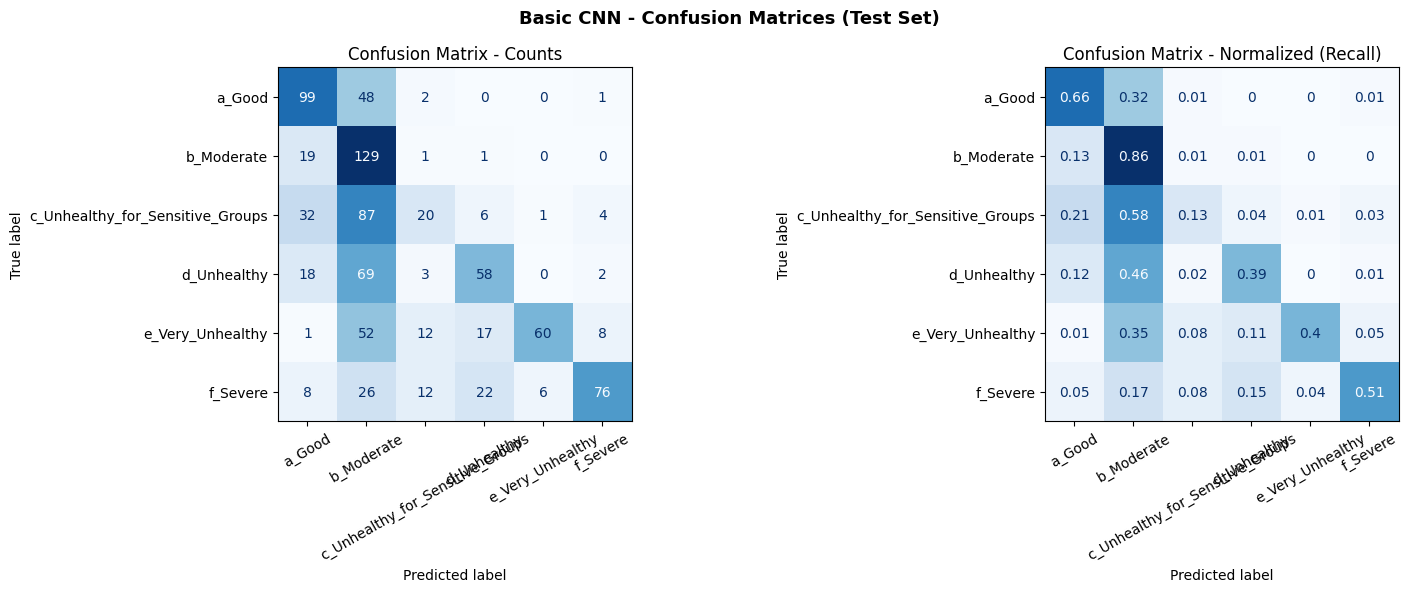

Saved to outputs/cm_basic_cnn.png


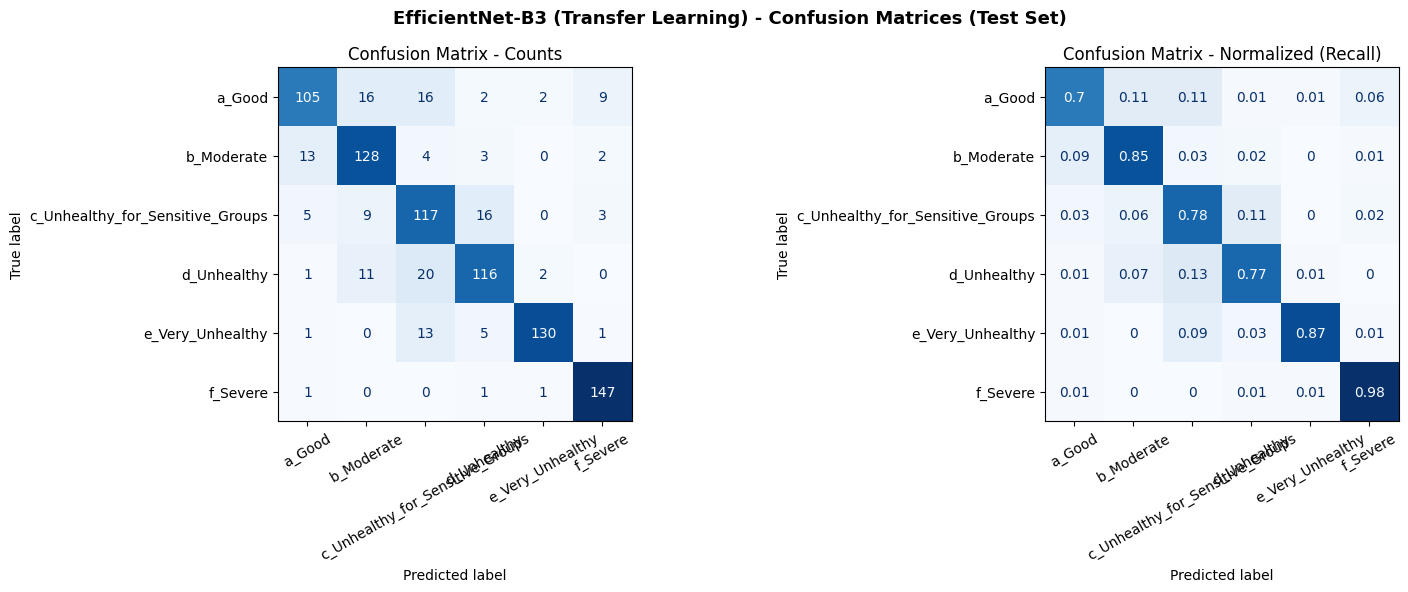

Saved to outputs/cm_efficientnet.png


In [24]:
class_names = list(le.classes_)

def plot_confusion_matrices(preds, labels, model_name, save_name):
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    disp1 = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp1.plot(ax=axes[0], colorbar=False, cmap="Blues")
    axes[0].set_title("Confusion Matrix - Counts", fontsize=12)
    axes[0].tick_params(axis="x", rotation=30)

    disp2 = ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=class_names)
    disp2.plot(ax=axes[1], colorbar=False, cmap="Blues")
    axes[1].set_title("Confusion Matrix - Normalized (Recall)", fontsize=12)
    axes[1].tick_params(axis="x", rotation=30)

    plt.suptitle(f"{model_name} - Confusion Matrices (Test Set)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, save_name), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to outputs/{save_name}")


plot_confusion_matrices(cnn_preds, cnn_labels, "Basic CNN", "cm_basic_cnn.png")
plot_confusion_matrices(tl_preds,  tl_labels,  "EfficientNet-B3 (Transfer Learning)", "cm_efficientnet.png")

### 4.6 Per-class Precision / Recall / F1 Bar Charts

Side-by-side bars highlight which AQI classes each model finds hardest to classify. Precision measures correctness among positive predictions; recall measures coverage of true positives; F1 is the harmonic mean of both.

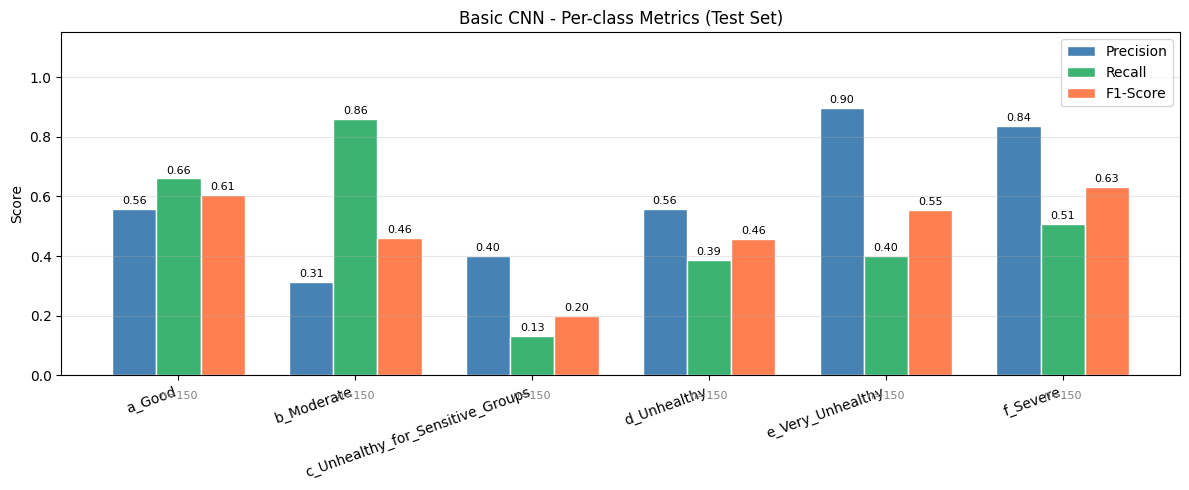

Saved to outputs/perclass_cnn.png


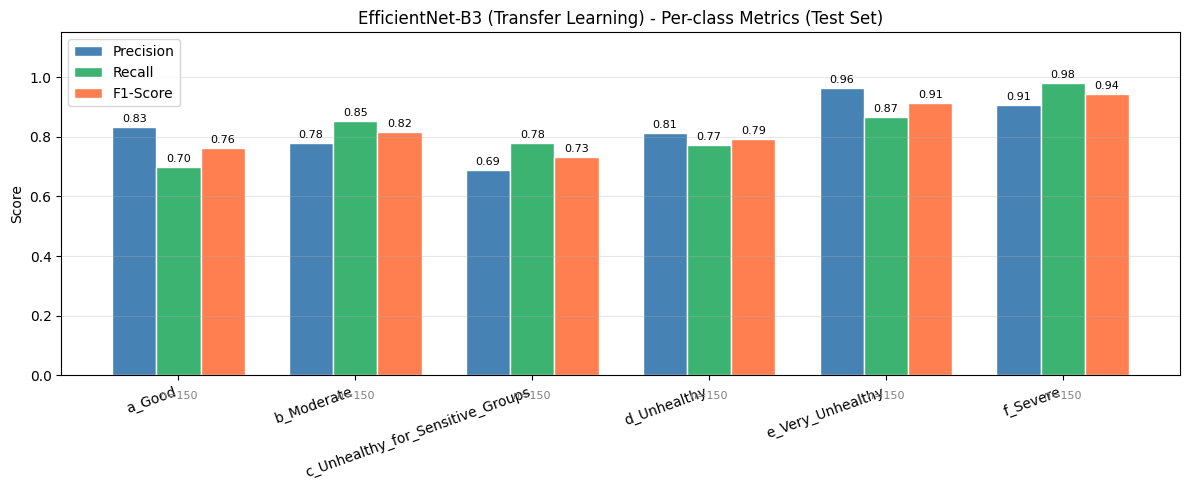

Saved to outputs/perclass_efficientnet.png


In [25]:
def plot_per_class_metrics(preds, labels, model_name, save_name):
    precision, recall, f1, support = precision_recall_fscore_support(
        labels, preds, labels=range(num_classes), zero_division=0
    )

    x     = np.arange(num_classes)
    width = 0.25

    fig, ax = plt.subplots(figsize=(max(8, num_classes * 2), 5))

    bars_p = ax.bar(x - width, precision, width, label="Precision", color="steelblue",     edgecolor="white")
    bars_r = ax.bar(x,         recall,    width, label="Recall",    color="mediumseagreen", edgecolor="white")
    bars_f = ax.bar(x + width, f1,        width, label="F1-Score",  color="coral",          edgecolor="white")

    for bars in [bars_p, bars_r, bars_f]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=20, ha="right")
    ax.set_ylim(0, 1.15)
    ax.set_title(f"{model_name} - Per-class Metrics (Test Set)", fontsize=12)
    ax.set_ylabel("Score")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    for i, s in enumerate(support):
        ax.text(i, -0.07, f"n={s}", ha="center", fontsize=8, color="grey",
                transform=ax.get_xaxis_transform())

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, save_name), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to outputs/{save_name}")


plot_per_class_metrics(cnn_preds, cnn_labels, "Basic CNN",                          "perclass_cnn.png")
plot_per_class_metrics(tl_preds,  tl_labels,  "EfficientNet-B3 (Transfer Learning)", "perclass_efficientnet.png")

---
# Task 5 - Training Curves

The plots below show epoch-by-epoch training loss, validation loss, training accuracy, and validation accuracy for both models. For the transfer learning model, the vertical dashed line marks the epoch where the backbone was unfrozen.

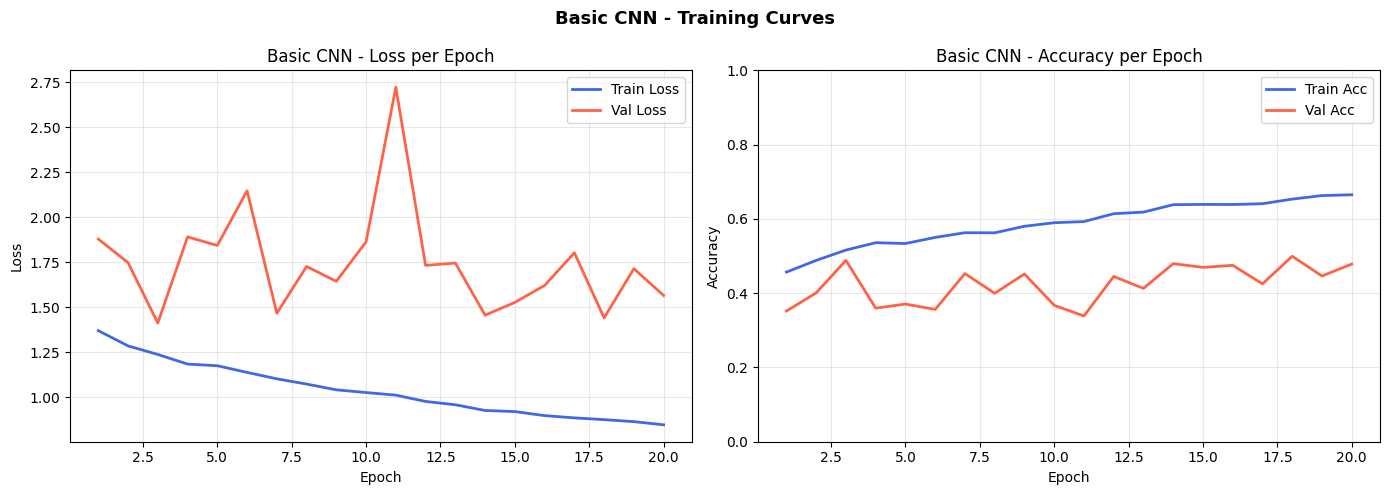

Saved to outputs/curves_cnn.png


In [26]:
# Training curves for the Basic CNN
epochs_cnn = range(1, CNN_EPOCHS + 1)
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_cnn, cnn_history["train_loss"], label="Train Loss", color="royalblue", lw=2)
axes[0].plot(epochs_cnn, cnn_history["val_loss"],   label="Val Loss",   color="tomato",    lw=2)
axes[0].set_title("Basic CNN - Loss per Epoch", fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_cnn, cnn_history["train_acc"], label="Train Acc", color="royalblue", lw=2)
axes[1].plot(epochs_cnn, cnn_history["val_acc"],   label="Val Acc",   color="tomato",    lw=2)
axes[1].set_title("Basic CNN - Accuracy per Epoch", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Basic CNN - Training Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "curves_cnn.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/curves_cnn.png")

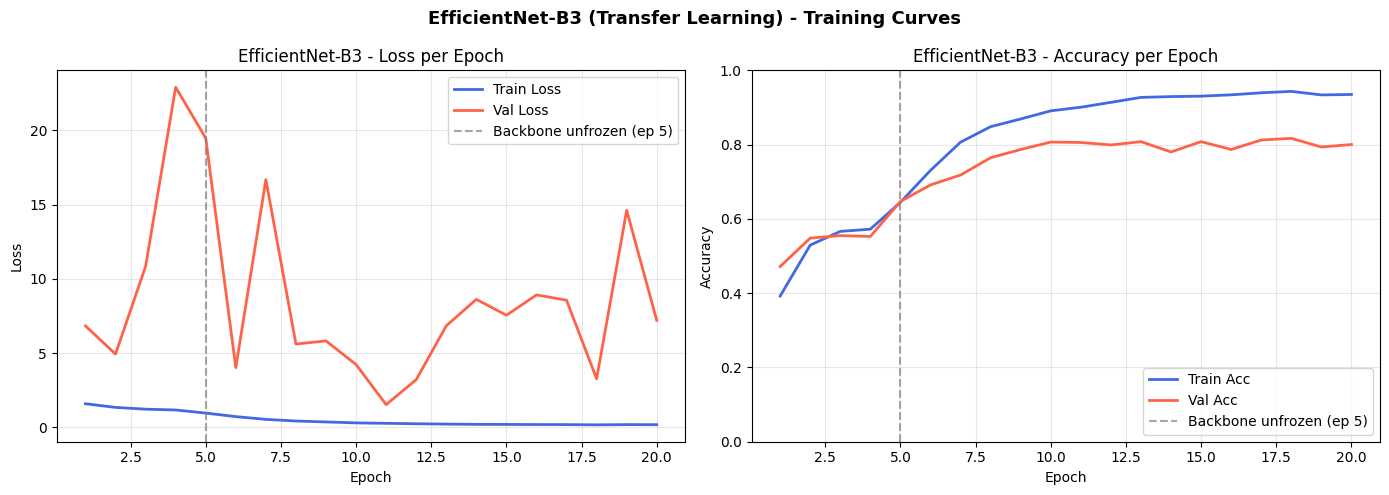

Saved to outputs/curves_efficientnet.png


In [27]:
# Training curves for EfficientNet-B3
epochs_tl = range(1, TL_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_tl, tl_history["train_loss"], label="Train Loss", color="royalblue", lw=2)
axes[0].plot(epochs_tl, tl_history["val_loss"],   label="Val Loss",   color="tomato",    lw=2)
axes[0].axvline(UNFREEZE_EPOCH, color="grey", linestyle="dashed", alpha=0.7,
                label=f"Backbone unfrozen (ep {UNFREEZE_EPOCH})")
axes[0].set_title("EfficientNet-B3 - Loss per Epoch", fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_tl, tl_history["train_acc"], label="Train Acc", color="royalblue", lw=2)
axes[1].plot(epochs_tl, tl_history["val_acc"],   label="Val Acc",   color="tomato",    lw=2)
axes[1].axvline(UNFREEZE_EPOCH, color="grey", linestyle="dashed", alpha=0.7,
                label=f"Backbone unfrozen (ep {UNFREEZE_EPOCH})")
axes[1].set_title("EfficientNet-B3 - Accuracy per Epoch", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("EfficientNet-B3 (Transfer Learning) - Training Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "curves_efficientnet.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/curves_efficientnet.png")

### 5.1 Discussion: Why Pretrained Models Often Outperform Models Trained from Scratch

**Feature reuse:** EfficientNet-B3 was pretrained on over 1.2 million ImageNet images. During that training it learned a rich hierarchy of visual features: low-level edge detectors and texture filters in early layers, and higher-level semantic representations (shapes, parts, scenes) in deeper layers. When fine-tuned on AQI images, these features do not need to be relearned from zero. The network only needs to adapt its high-level representations to the specific task of distinguishing haze and pollution levels.

**Data efficiency:** AQI classification datasets are relatively small compared to ImageNet. A CNN trained from scratch on a small dataset is prone to overfitting because it has no prior knowledge of visual structure. A pretrained model starts from a much better initialization, so it generalizes well even with limited data.

**Faster convergence:** Because the backbone already produces meaningful feature maps from epoch one, the classifier head can reach good accuracy within a few epochs. A scratch-trained CNN must first learn basic feature detectors before it can classify reliably, requiring more epochs and more data.

**Transfer learning on this dataset:** AQI classification is a visually subtle task. Differences between classes like Moderate and Unhealthy often manifest as gradual changes in haze density, sky color, and visibility. The texture and scene-level features learned by EfficientNet on ImageNet transfer well to this domain, because the underlying visual patterns (color gradients, contrast, atmospheric scattering effects) are captured by general-purpose convolutional filters. The improvement in F1 and accuracy over the basic CNN is expected and consistent with this reasoning.

---
# Task 6 - Misclassification Analysis

We identify 5 to 10 misclassified images from the test set for each model, visualize them alongside their predicted and actual class labels, and provide possible reasons for the errors.

In [30]:
def plot_misclassifications(preds, labels, model_name, save_name, n=10):
    """
    Find misclassified test samples and visualize them with predicted and actual labels.

    Parameters
    ----------
    preds      : numpy array of predicted class indices
    labels     : numpy array of true class indices
    model_name : string label for the title
    save_name  : filename to save the figure
    n          : number of misclassified images to display (default 10)
    """
    # Indices in the test dataframe corresponding to wrong predictions
    wrong_idx = np.where(preds != labels)[0]
    print(f"{model_name}: {len(wrong_idx)} misclassifications out of {len(labels)} test samples.")

    # Sample up to n without replacement
    sample_size = min(n, len(wrong_idx))
    rng = np.random.default_rng(SEED)
    chosen = rng.choice(wrong_idx, size=sample_size, replace=False)

    test_df_reset = test_df.reset_index(drop=True)

    ncols = 5
    nrows = (sample_size + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3.5))
    axes = axes.flatten()

    for plot_i, test_i in enumerate(chosen):
        row   = test_df_reset.iloc[test_i]
        fpath = os.path.join(IMAGE_DIR, str(row["Filename"]).strip())

        try:
            img = Image.open(fpath).convert("RGB")
        except FileNotFoundError:
            img = Image.fromarray(np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8))

        true_cls = le.classes_[labels[test_i]]
        pred_cls = le.classes_[preds[test_i]]

        axes[plot_i].imshow(img)
        axes[plot_i].set_title(
            f"True: {true_cls}\nPred: {pred_cls}",
            fontsize=8,
            color="red"
        )
        axes[plot_i].axis("off")

    # Hide any unused subplot axes
    for j in range(sample_size, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"{model_name} - Misclassified Test Images", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, save_name), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to outputs/{save_name}")


print("Misclassification plot function defined.")

Misclassification plot function defined.


Basic CNN: 458 misclassifications out of 900 test samples.


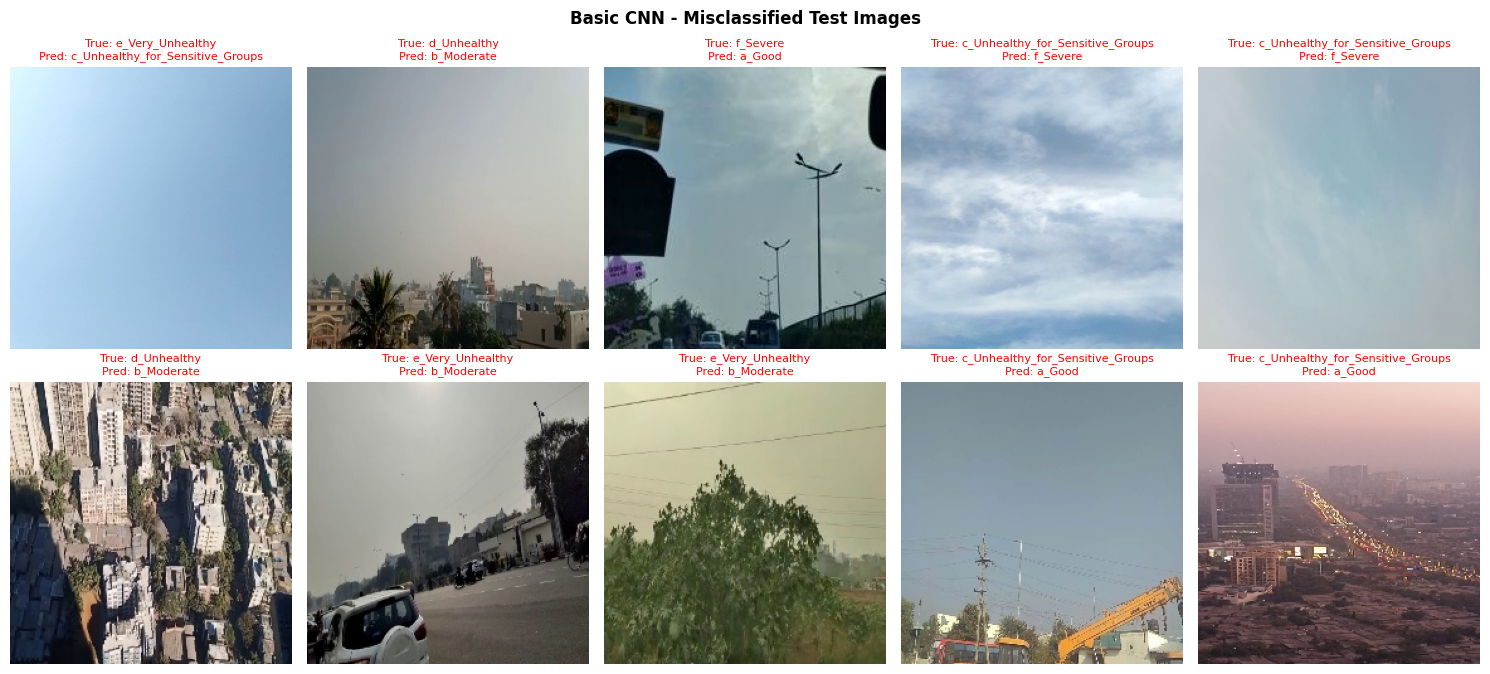

Saved to outputs/misclass_cnn.png


In [31]:
plot_misclassifications(cnn_preds, cnn_labels, "Basic CNN", "misclass_cnn.png", n=10)

EfficientNet-B3 (Transfer Learning): 157 misclassifications out of 900 test samples.


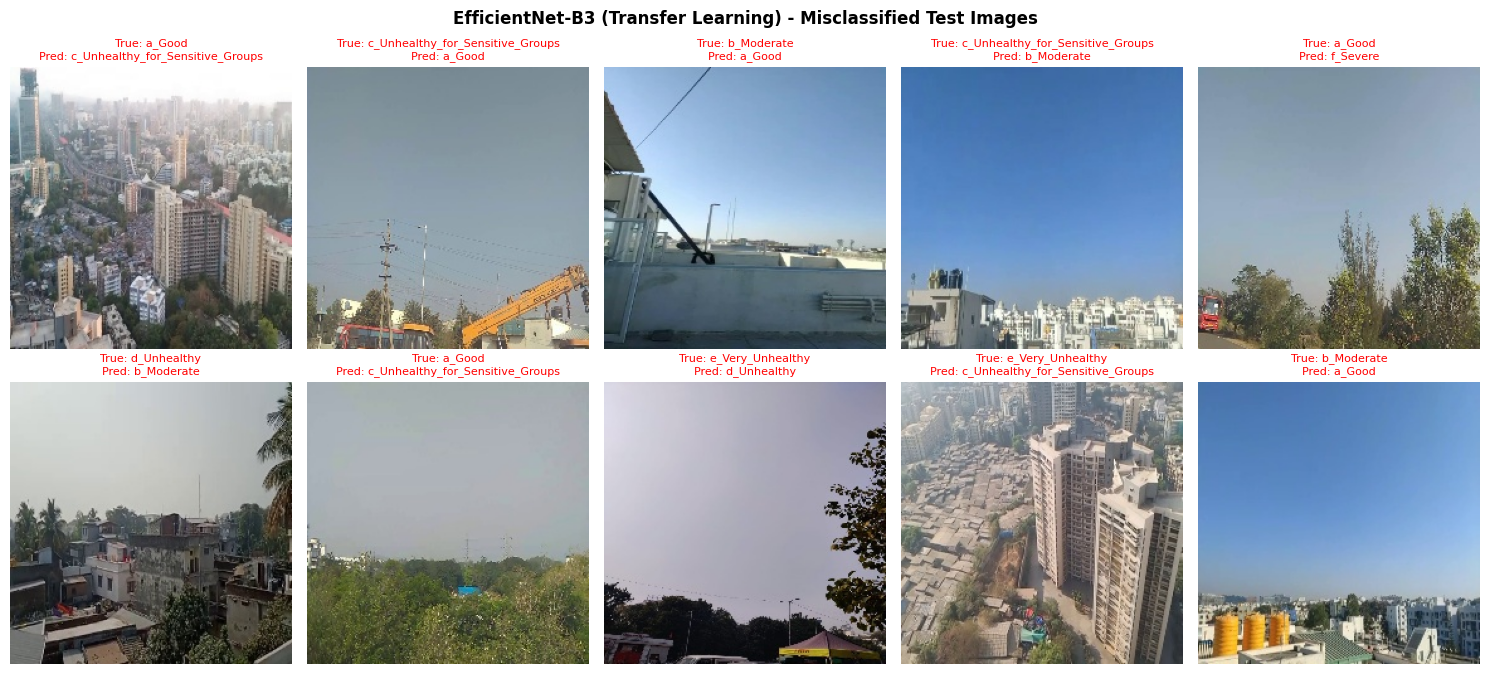

Saved to outputs/misclass_efficientnet.png


In [32]:
plot_misclassifications(tl_preds, tl_labels, "EfficientNet-B3 (Transfer Learning)", "misclass_efficientnet.png", n=10)

### 6.1 Discussion: Possible Reasons for Misclassification

**1. Visual ambiguity between adjacent classes.**
AQI classes like Moderate, Unhealthy for Sensitive Groups, and Unhealthy represent a continuous spectrum of air quality. Images at the boundary between two neighboring classes can look virtually identical. Slight differences in haze density, lighting conditions, or camera exposure can make a Moderate scene appear Unhealthy and vice versa.

**2. Scene and camera variability.**
Images in the dataset are captured under a wide variety of conditions: different times of day, weather, seasons, geographic locations, and camera settings. A sunny midday photo may have artificially high contrast that makes clean air look hazier. Overcast lighting can suppress the visual cues the model relies on. These confounding factors push images toward the wrong class.

**3. Class imbalance effects.**
The dataset is not perfectly balanced. Classes with fewer training samples receive fewer gradient updates. The model may develop a mild bias toward high-frequency classes, which can cause it to misclassify rare classes toward more common neighbors.

**4. Limited spatial context.**
The model sees only a single cropped and resized 224x224 frame. In some images the most informative region (distant skyline, mountain visibility, or urban haze layer) may be cropped out or fall outside the model's receptive field. Richer multi-scale or multi-crop inference could reduce these errors.

**5. Limitations of the basic CNN.**
The scratch-trained CNN has a shallower representation capacity and no prior knowledge of textures and global scene structure. It is more likely to overfit to color statistics rather than genuine structural haze cues, leading to higher misclassification rates, especially on visually complex or ambiguous samples.